In [4]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import cobra
import numpy as np
import pandas as pd

MODEL_PATH = Path("../model/Rpom_05.xml")
TARGET_MU = 0.22
GLUCOSE_UPTAKE = -5.44
ACETATE_UPTAKE = -15.01
BASELINE_ATPM = 3.15
ATPM_SCAN_MAX = 80.0


@dataclass
class Scenario:
    name: str
    setup: Callable[[cobra.Model], None] | None = None


def configure_carbon(model: cobra.Model, glucose: float, acetate: float) -> None:
    model.reactions.get_by_id("EX_glc").bounds = (glucose, 0.0) if glucose < 0 else (0.0, 0.0)
    model.reactions.get_by_id("EX_ac").bounds = (acetate, 0.0) if acetate < 0 else (0.0, 0.0)


def growth_rate(model: cobra.Model, atpm: float) -> float:
    model.reactions.get_by_id("ATPM").bounds = (atpm, atpm)
    sol = model.optimize()
    return float(sol.objective_value or 0.0)


def atpm_for_target_mu(
    model: cobra.Model,
    glucose: float,
    acetate: float,
    target_mu: float = TARGET_MU,
    lo: float = 0.0,
    hi: float = ATPM_SCAN_MAX,
) -> float:
    configure_carbon(model, glucose, acetate)

    mu_lo = growth_rate(model, lo)
    mu_hi = growth_rate(model, hi)
    if (mu_lo - target_mu) * (mu_hi - target_mu) > 0:
        return float("nan")

    for _ in range(60):
        mid = 0.5 * (lo + hi)
        mu_mid = growth_rate(model, mid)
        if (mu_lo - target_mu) * (mu_mid - target_mu) <= 0:
            hi = mid
            mu_hi = mu_mid
        else:
            lo = mid
            mu_lo = mu_mid
    return 0.5 * (lo + hi)


def set_biomass_gam(model: cobra.Model, atp_coeff: float) -> None:
    biomass = model.reactions.get_by_id("Rpom_hwa_biomass")
    atp = model.metabolites.get_by_id("ATP[c]")
    adp = model.metabolites.get_by_id("ADP[c]")
    pi = model.metabolites.get_by_id("Pi[c]")
    h = model.metabolites.get_by_id("PROTON[c]")

    current = -biomass.metabolites[atp]
    delta = atp_coeff - current
    biomass.add_metabolites({atp: -delta, adp: delta, pi: delta, h: delta})


def scenario_ppdk_forward_only(model: cobra.Model) -> None:
    model.reactions.get_by_id("PYRUVATEORTHOPHOSPHATE-DIKINASE-RXN").lower_bound = 0.0


def scenario_disable_ed(model: cobra.Model) -> None:
    for rid in [
        "GLU6PDEHYDROG-RXN",
        "6PGLUCONOLACT-RXN",
        "PGLUCONDEHYDRAT-RXN",
        "KDPGALDOL-RXN",
    ]:
        model.reactions.get_by_id(rid).knock_out()


def scenario_disable_complex_i(model: cobra.Model) -> None:
    model.reactions.get_by_id("NADH-DEHYDROG-A-RXN").knock_out()


def scenario_non_pumping_complex_i(model: cobra.Model) -> None:
    # Approximate NDH-II/NQR-like NADH oxidation by removing proton translocation from NDH-I.
    rxn = model.reactions.get_by_id("NADH-DEHYDROG-A-RXN")
    rxn.subtract_metabolites(dict(rxn.metabolites))
    rxn.add_metabolites(
        {
            model.metabolites.get_by_id("NADH[c]"): -1.0,
            model.metabolites.get_by_id("PROTON[c]"): -1.0,
            model.metabolites.get_by_id("UBIQUINONE-10[c]"): -1.0,
            model.metabolites.get_by_id("CPD-9958[c]"): 1.0,
            model.metabolites.get_by_id("NAD[c]"): 1.0,
        }
    )
    rxn.bounds = (0.0, 1000.0)


def scenario_gam50(model: cobra.Model) -> None:
    set_biomass_gam(model, atp_coeff=50.0)


def scenario_complex_i_less_coupled_plus_gam50(model: cobra.Model) -> None:
    scenario_non_pumping_complex_i(model)
    scenario_gam50(model)


def evaluate_scenario(base_model: cobra.Model, scenario: Scenario) -> dict[str, float | str]:
    with base_model:
        if scenario.setup is not None:
            scenario.setup(base_model)

        configure_carbon(base_model, GLUCOSE_UPTAKE, 0.0)
        mu_glc_at_baseline_atpm = growth_rate(base_model, BASELINE_ATPM)

        configure_carbon(base_model, 0.0, ACETATE_UPTAKE)
        mu_ac_at_baseline_atpm = growth_rate(base_model, BASELINE_ATPM)

        configure_carbon(base_model, GLUCOSE_UPTAKE, 0.0)
        atpm_for_target = atpm_for_target_mu(base_model, GLUCOSE_UPTAKE, 0.0, target_mu=TARGET_MU)

    return {
        "scenario": scenario.name,
        "mu_glc_at_ATPM3.15": mu_glc_at_baseline_atpm,
        "mu_ac_at_ATPM3.15": mu_ac_at_baseline_atpm,
        "ATPM_for_mu0.22_glc": atpm_for_target,
    }


def main() -> None:
    model = cobra.io.read_sbml_model(str(MODEL_PATH))

    scenarios = [
        Scenario("baseline", None),
        Scenario("PPDK_forward_only", scenario_ppdk_forward_only),
        Scenario("ED_pathway_disabled", scenario_disable_ed),
        Scenario("ComplexI_disabled", scenario_disable_complex_i),
        Scenario("ComplexI_non_pumping", scenario_non_pumping_complex_i),
        Scenario("GAM_50ATP", scenario_gam50),
        Scenario("ComplexI_non_pumping_plus_GAM_50ATP", scenario_complex_i_less_coupled_plus_gam50),
    ]

    rows = [evaluate_scenario(model, s) for s in scenarios]
    df = pd.DataFrame(rows).sort_values("ATPM_for_mu0.22_glc")

    out_dir = Path("analysis/glucose_overgrowth_20260305")
    out_dir.mkdir(parents=True, exist_ok=True)

    out_csv = out_dir / "hypothesis_summary.csv"
    df.to_csv(out_csv, index=False)

    print("Saved:", out_csv)
    print(df.to_string(index=False))

    # One focused diagnostic: ATP-producing reactions on glucose at baseline.
    with model:
        configure_carbon(model, GLUCOSE_UPTAKE, 0.0)
        model.reactions.get_by_id("ATPM").bounds = (BASELINE_ATPM, BASELINE_ATPM)
        sol = cobra.flux_analysis.pfba(model)
        atp = model.metabolites.get_by_id("ATP[c]")
        records = []
        for rxn in atp.reactions:
            net = rxn.metabolites[atp] * sol.fluxes[rxn.id]
            if abs(net) > 1e-6:
                records.append((rxn.id, float(sol.fluxes[rxn.id]), float(net)))
        atp_df = pd.DataFrame(records, columns=["reaction", "flux", "ATP_net"])
        atp_out = out_dir / "atp_budget_glucose_baseline.csv"
        atp_df.sort_values("ATP_net", ascending=False).to_csv(atp_out, index=False)
        print("Saved:", atp_out)

In [5]:
main()

/Users/acheron/micromamba/envs/rpom/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Saved: analysis/glucose_overgrowth_20260305/hypothesis_summary.csv
                           scenario  mu_glc_at_ATPM3.15  mu_ac_at_ATPM3.15  ATPM_for_mu0.22_glc
                ED_pathway_disabled            0.217473           0.378317             2.818617
ComplexI_non_pumping_plus_GAM_50ATP            0.422146           0.297446            26.885173
                  ComplexI_disabled            0.474594           0.334016            30.985578
               ComplexI_non_pumping            0.474594           0.334016            30.985578
                          GAM_50ATP            0.501153           0.343985            46.019335
                  PPDK_forward_only            0.546517           0.347615            49.941737
                           baseline            0.551659           0.378317            50.119740
Saved: analysis/glucose_overgrowth_20260305/atp_budget_glucose_baseline.csv


In [6]:
import sys
from helpers import *
if ".." not in sys.path:
    sys.path.append("..")
    
import cobra
import pandas as pd
from cobra.io import read_sbml_model
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

model = read_sbml_model("../model/Rpom_05.xml")
model



Name,Rpom_05
Memory address,318d417c0
Number of metabolites,1782
Number of reactions,1786
Number of genes,974
Number of groups,0
Objective expression,1.0*Rpom_hwa_biomass - 1.0*Rpom_hwa_biomass_reverse_5ec2f
Compartments,"c, p, e"


In [7]:
model.reactions.get_by_id("NADH-DEHYDROG-A-RXN")

Reaction identifier,NADH-DEHYDROG-A-RXN
Name,
Memory address,0x330c51c70
Stoichiometry,NADH[c] + 5.0 PROTON[c] + UBIQUINONE-10[c] <=> CPD-9958[c] + NAD[c] + 4.0 PROTON[e] NADH + 5.0 H+ + ubiquinone-10 <=> ubiquinol-10 + NAD+ + 4.0 H+
GPR,SPO2786 and SPO2785 and SPO2782 and SPO2774 and SPO2772 and SPO2770 and SPO2767 and SPO2766 and...
Lower bound,-1000.0
Upper bound,1000.0


In [22]:
ATPM_space = np.linspace(0,50,100)
growth_rates = []
growth_rates_ac = []

with model:
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    
    # key knockouts
    model.reactions.get_by_id("METHYLENETHFDEHYDROG-NADP-RXN").knock_out()
    model.reactions.get_by_id("RXN0-300").knock_out()
    model.reactions.get_by_id("GLYCERATE-DEHYDROGENASE-RXN").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NADP/WATER//OXALACETIC_ACID/AMMONIUM/NADPH/PROTON.62.").knock_out()
    model.reactions.get_by_id("1.4.1.21-RXN-L-ASPARTATE/NAD/WATER//OXALACETIC_ACID/AMMONIUM/NADH/PROTON.60.").knock_out()
    model.reactions.get_by_id("NADH-KINASE-RXN").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADPH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NADP/WATER.70.").knock_out()
    model.reactions.get_by_id("R501-RXN-CPD-821/NADH/OXYGEN-MOLECULE/PROTON//CPD-904/FORMALDEHYDE/NAD/WATER.68.").knock_out()
    model.reactions.get_by_id("RXN0-3962").knock_out()
    
    # =====================================================================
    # COMMON METABOLITES
    # =====================================================================
    WATER = model.metabolites.get_by_id("WATER[c]")
    Pi = model.metabolites.get_by_id("Pi[c]")
    PROTON = model.metabolites.get_by_id("PROTON[c]")
    G3P = model.metabolites.get_by_id("GLYCEROL-3P[c]")
    CTP = model.metabolites.get_by_id("CTP[c]")
    PPI = model.metabolites.get_by_id("PPI[c]")
    CMP = model.metabolites.get_by_id("CMP[c]")
    SER = model.metabolites.get_by_id("SER[c]")
    CO2 = model.metabolites.get_by_id("CARBON-DIOXIDE[c]")
    COA = model.metabolites.get_by_id("CO-A[c]")
    ATP = model.metabolites.get_by_id("ATP[c]")
    ADP = model.metabolites.get_by_id("ADP[c]")
    NADH = model.metabolites.get_by_id("NADH[c]")
    NAD = model.metabolites.get_by_id("NAD[c]")
    O2 = model.metabolites.get_by_id("OXYGEN-MOLECULE[c]")
    orn = model.metabolites.get_by_id("L-ORNITHINE[c]")
    gln = model.metabolites.get_by_id("GLN[c]")
    ACP = model.metabolites.get_by_id("ACP[c]")
    
    # =====================================================================
    # Fix NADH dehydrogenase (e → p)
    # =====================================================================
    model.reactions.get_by_id("NADH-DEHYDROG-A-RXN").knock_out()
    rxn_ndh = cobra.Reaction("NADH-DEHYDROG-A-RXN_2")
    rxn_ndh.add_metabolites({
        NADH: -1, 
        model.metabolites.get_by_id("PROTON[c]"): -1,
        model.metabolites.get_by_id("UBIQUINONE-10[c]"): -1,
        model.metabolites.get_by_id("CPD-9958[c]"): 1, 
        NAD: 1
        #model.metabolites.get_by_id("PROTON[p]"): 0
    })
    rxn_ndh.bounds = (0, 1000)
    model.add_reactions([rxn_ndh])

    # =====================================================================
    # TEST GROWTH
    # =====================================================================
    model.objective = "Rpom_hwa_biomass"
    
    model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
    model.reactions.get_by_id("EX_ac").bounds = (0, 0)
    sol_glc = model.optimize()
    print(f"\nGlucose growth: {sol_glc.objective_value:.4f}")
    
    model.reactions.get_by_id("EX_glc").bounds = (0, 0)
    model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
    sol_ac = model.optimize()
    print(f"Acetate growth:  {sol_ac.objective_value:.4f}")
    
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_ac").bounds = (0, 0)
        model.reactions.get_by_id("EX_glc").bounds = (-5.44, 0)
        sol = model.optimize()
        growth_rates.append(sol.objective_value)
    
    for level in tqdm(ATPM_space):
        model.reactions.get_by_id("ATPM").bounds = (level, level)
        model.reactions.get_by_id("EX_glc").bounds = (0, 0)
        model.reactions.get_by_id("EX_ac").bounds = (-15.01, 0)
        sol = model.optimize()
        growth_rates_ac.append(sol.objective_value)


Glucose growth: 0.4820
Acetate growth:  0.3515


100%|██████████| 100/100 [00:01<00:00, 65.76it/s]


In [11]:
model.metabolites.get_by_id("CPD-9958[c]")

Metabolite identifier,CPD-9958[c]
Name,ubiquinol-10
Memory address,0x3195cd3d0
Formula,C59H92O4
Compartment,c
In 7 reaction(s),"1.10.2.2-RXN, SUCCINATE-DEHYDROGENASE-UBIQUINONE-RXN, RXN-20992, NADH-DEHYDROG-A-RXN, RXN-14903, RXN-9237, 1.5.5.1-RXN-ETF-Reduced/UBIQUINONE-10//ETF-Oxidized/CPD-9958/PROTON.56."


/var/folders/8f/167j3z857g1cpb6_79vckdjc0000gn/T/ipykernel_59751/1488089653.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


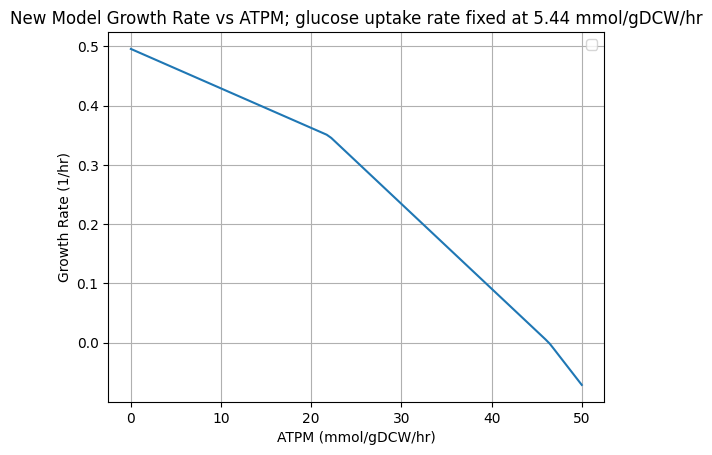

In [21]:
plt.plot(ATPM_space, growth_rates)
plt.title("New Model Growth Rate vs ATPM; glucose uptake rate fixed at 5.44 mmol/gDCW/hr")
plt.xlabel("ATPM (mmol/gDCW/hr)")
plt.ylabel("Growth Rate (1/hr)")
plt.grid()
plt.legend()
plt.show()


/var/folders/8f/167j3z857g1cpb6_79vckdjc0000gn/T/ipykernel_59751/2819002235.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


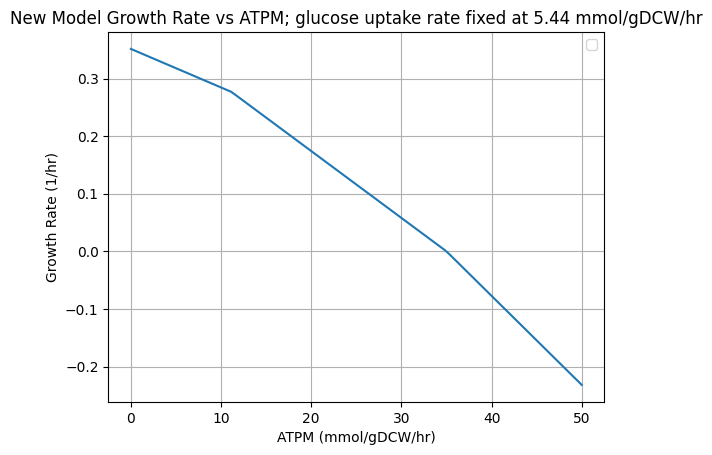

In [24]:
plt.plot(ATPM_space, growth_rates_ac)
plt.title("New Model Growth Rate vs ATPM; glucose uptake rate fixed at 5.44 mmol/gDCW/hr")
plt.xlabel("ATPM (mmol/gDCW/hr)")
plt.ylabel("Growth Rate (1/hr)")
plt.grid()
plt.legend()
plt.show()
